# Phase 2 — Player & Team Form Exploration

Exploring the analytics views in `sql/analytics.sql` against real ingested 2026/27 season data. Re-run this notebook any time after a fresh ingestion (`python -m src.ingestion.load`) to refresh with the latest gameweek.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", message=".*only supports SQLAlchemy.*")

import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

from config import settings

conn = psycopg2.connect(settings.DATABASE_URL)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)

## Player season totals

Top scorers, most efficient per-90 performers, and best value-for-money picks so far this season. `points_per_90` and `points_per_million` matter more than raw totals this early — a player with 2 starts already tells you more per-90 than one with a single 60-minute cameo.

In [2]:
position_names = {1: "GKP", 2: "DEF", 3: "MID", 4: "FWD"}

totals = pd.read_sql_query("SELECT * FROM v_player_season_totals", conn)
totals["position"] = totals["element_type"].map(position_names)

print("Top 10 by total points:")
totals.sort_values("total_points", ascending=False)[
    ["web_name", "position", "total_points", "points_per_game", "games_played"]
].head(10)

Top 10 by total points:


,web_name,position,total_points,points_per_game,games_played
119,White,DEF,11,11.0,1
108,Ødegaard,MID,11,11.0,1
195,Saka,MID,9,9.0,1
353,Calafiori,DEF,9,9.0,1
67,Raya,GKP,6,6.0,1
177,Havertz,FWD,6,6.0,1
285,Tzolis,MID,6,6.0,1
433,Mosquera,DEF,6,6.0,1
204,Gabriel,DEF,5,5.0,1
135,Rice,MID,3,3.0,1


In [3]:
print("Top 10 by points per 90 (min 45 minutes played):")
totals[totals["total_minutes"] >= 45].sort_values("points_per_90", ascending=False)[
    ["web_name", "position", "points_per_90", "total_points", "total_minutes"]
].head(10)

Top 10 by points per 90 (min 45 minutes played):


,web_name,position,points_per_90,total_points,total_minutes
108,Ødegaard,MID,13.20,11,75
195,Saka,MID,12.09,9,67
119,White,DEF,11.00,11,90
353,Calafiori,DEF,10.13,9,80
285,Tzolis,MID,7.20,6,75
67,Raya,GKP,6.00,6,90
433,Mosquera,DEF,6.00,6,90
177,Havertz,FWD,6.00,6,90
204,Gabriel,DEF,5.00,5,90
135,Rice,MID,4.03,3,67


In [4]:
print("Top 10 value picks (points per GBP million):")
totals[totals["total_minutes"] >= 45].sort_values("points_per_million", ascending=False)[
    ["web_name", "position", "now_cost", "total_points", "points_per_million", "selected_by_percent"]
].head(10)

Top 10 value picks (points per GBP million):


,web_name,position,now_cost,total_points,points_per_million,selected_by_percent
119,White,DEF,55,11,2.00,4.5
108,Ødegaard,MID,65,11,1.69,8.2
353,Calafiori,DEF,55,9,1.64,39.8
433,Mosquera,DEF,55,6,1.09,6.4
67,Raya,GKP,60,6,1.00,37.6
195,Saka,MID,95,9,0.95,9.4
285,Tzolis,MID,65,6,0.92,25.2
177,Havertz,FWD,75,6,0.80,5.5
204,Gabriel,DEF,80,5,0.63,29.7
425,Lewis-Skelly,MID,55,3,0.55,0.7


## Rolling & weighted form

With only GW1 played, every rolling window (3-GW, 5-GW, recency-weighted) necessarily equals that single gameweek's score — that's correct behavior, not a bug. This becomes genuinely useful once there's a run of gameweeks to distinguish real form from a one-off explosion or a quiet week.

In [5]:
form = pd.read_sql_query("""
    SELECT rf.player_code, p.web_name, rf.event_id, rf.total_points,
           rf.points_avg_3gw, rf.points_avg_5gw, wf.weighted_points_form
    FROM v_player_rolling_form rf
    JOIN v_player_weighted_form wf USING (season, event_id, player_code)
    JOIN players p ON p.player_code = rf.player_code
    ORDER BY rf.event_id DESC, rf.total_points DESC
""", conn)

latest_gw = form["event_id"].max()
print(f"Form leaderboard, GW{latest_gw}:")
form[form["event_id"] == latest_gw].head(10)

Form leaderboard, GW1:


,player_code,web_name,event_id,total_points,points_avg_3gw,points_avg_5gw,weighted_points_form
0,184029,Ødegaard,1,11,11.0,11.0,11.0
1,198869,White,1,11,11.0,11.0,11.0
2,223340,Saka,1,9,9.0,9.0,9.0
3,466075,Calafiori,1,9,9.0,9.0,9.0
4,219847,Havertz,1,6,6.0,6.0,6.0
5,154561,Raya,1,6,6.0,6.0,6.0
6,439509,Tzolis,1,6,6.0,6.0,6.0
7,500040,Mosquera,1,6,6.0,6.0,6.0
8,226597,Gabriel,1,5,5.0,5.0,5.0
9,204480,Rice,1,3,3.0,3.0,3.0


## Team form & upcoming fixture difficulty

Team attacking/defensive form (goals for/against, rolling last 5 matches — again, thin with one match played) and the v1 Fixture Difficulty Score for each team's next unplayed fixture. **Lower score = easier fixture.** Teams with no played match yet correctly show 0.000 rather than a fabricated confident number.

In [6]:
team_form = pd.read_sql_query("""
    SELECT t.short_name, ltf.attack_form_5, ltf.defense_form_5
    FROM v_team_latest_form ltf
    JOIN teams t ON t.team_code = ltf.team_code
    ORDER BY ltf.attack_form_5 DESC
""", conn)
print(f"Teams with at least one played match: {len(team_form)} / 20")
team_form

Teams with at least one played match: 2 / 20


,short_name,attack_form_5,defense_form_5
0,ARS,3.0,0.0
1,COV,0.0,3.0


In [7]:
fixture_difficulty = pd.read_sql_query("""
    SELECT DISTINCT ON (fd.team_code)
           th.short_name AS team, ta.short_name AS opponent, fd.is_home,
           fd.fpl_fdr, fd.fixture_difficulty_score, fd.kickoff_time
    FROM v_fixture_difficulty fd
    JOIN teams th ON th.team_code = fd.team_code
    JOIN teams ta ON ta.team_code = fd.opponent_code
    ORDER BY fd.team_code, fd.kickoff_time
""", conn)

print("Each team's very next fixture, easiest to hardest:")
fixture_difficulty.sort_values("fixture_difficulty_score")

Each team's very next fixture, easiest to hardest:


,team,opponent,is_home,fpl_fdr,fixture_difficulty_score,kickoff_time
7,COV,HUL,True,2,-0.271,2026-08-29 14:00:00+00:00
10,NFO,LEE,True,2,-0.200,2026-08-22 14:00:00+00:00
13,IPS,SUN,True,2,-0.200,2026-08-22 14:00:00+00:00
12,BHA,AVL,True,3,-0.100,2026-08-23 13:00:00+00:00
8,EVE,CRY,True,3,-0.100,2026-08-22 14:00:00+00:00
14,MCI,BOU,True,3,-0.100,2026-08-23 13:00:00+00:00
19,BRE,TOT,True,3,-0.100,2026-08-22 16:30:00+00:00
3,NEW,LIV,True,4,0.000,2026-08-23 15:30:00+00:00
15,FUL,CHE,True,4,0.000,2026-08-24 19:00:00+00:00
17,HUL,MUN,True,4,0.000,2026-08-22 11:30:00+00:00


## Ownership & transfer movers

Who the rest of the FPL population is moving toward this gameweek — useful both for template/differential thinking and as an early signal for price rises.

In [8]:
movers = pd.read_sql_query("SELECT * FROM v_ownership_movers", conn)
movers["position"] = movers["element_type"].map(position_names)

print("Biggest net transfers in this gameweek:")
movers.sort_values("net_transfers_event", ascending=False)[
    ["web_name", "position", "now_cost", "selected_by_percent", "net_transfers_event", "status"]
].head(10)

Biggest net transfers in this gameweek:


,web_name,position,now_cost,selected_by_percent,net_transfers_event,status
7,Calafiori,DEF,55,39.8,21083,a
28,Tzolis,MID,65,25.2,14417,a
24,Havertz,FWD,75,5.5,11331,a
14,Ødegaard,MID,65,8.2,7503,a
539,Van Hecke,DEF,50,10.8,5236,a
32,Cash,DEF,45,8.9,5064,a
169,João Pedro,FWD,75,64.4,3762,a
148,James,DEF,55,10.0,3725,a
466,Shaw,DEF,45,21.7,3177,a
429,Gvardiol,DEF,55,11.0,3161,a


## Top value picks, visualized

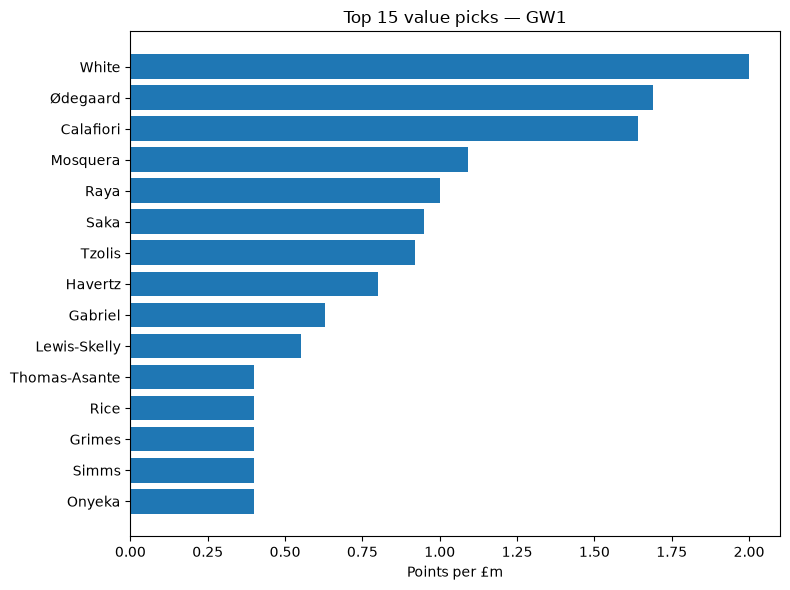

In [9]:
top_value = totals[totals["total_minutes"] >= 45].sort_values(
    "points_per_million", ascending=False
).head(15)[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_value["web_name"], top_value["points_per_million"])
ax.set_xlabel("Points per \u00a3m")
ax.set_title(f"Top 15 value picks \u2014 GW{latest_gw}")
plt.tight_layout()
plt.show()

## Next steps

This covers Phase 2. Phase 3 builds a Streamlit MVP dashboard on top of these same views; Phase 4 is where actual prediction models (expected points, expected minutes) get built, replacing "season-to-date average" with a real forecast.

In [10]:
conn.close()